#**Core Model Building**

##Loading MNIST Dataset

Data loaded and normalized.


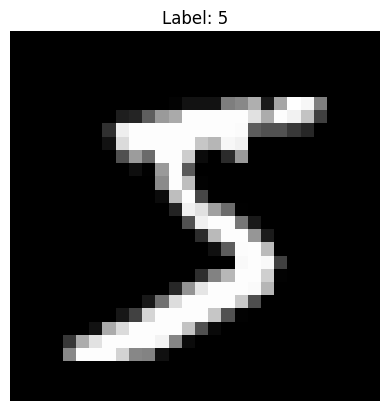

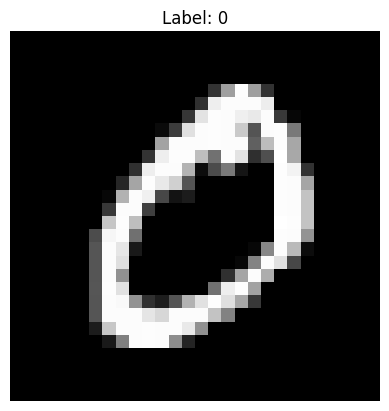

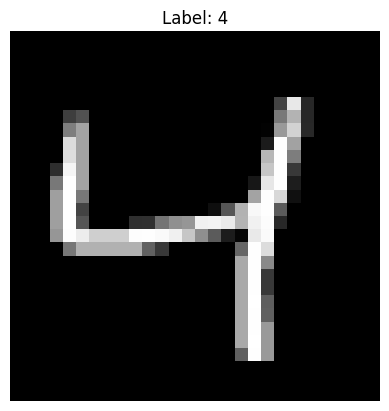

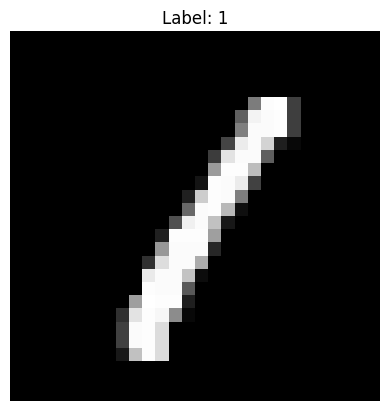

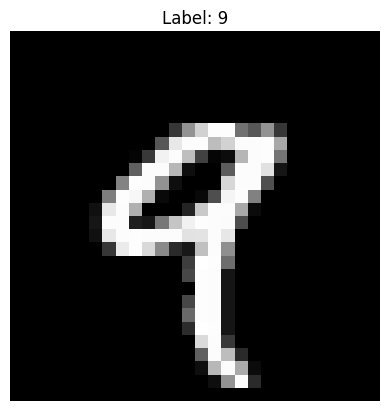

In [25]:
# Import necessary libraries
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.initializers import RandomNormal, GlorotNormal, Constant
import matplotlib.pyplot as plt

# Load and preprocess the MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize data (0-255 to 0-1)
x_train, x_test = x_train / 255.0, x_test / 255.0

# Create validation split from the training set
x_val, y_val = x_train[-10000:], y_train[-10000:]
x_train, y_train = x_train[:-10000], y_train[:-10000]

print("Data loaded and normalized.")

# Display the first five rows of data
for i in range(5):
    plt.imshow(x_train[i], cmap='gray')  # Display the image
    plt.title(f"Label: {y_train[i]}")    # Display the corresponding label
    plt.axis('off')                       # Hide axes
    plt.show()

##Helper Function for Plotting Learning Curves


In [26]:
# Helper function to plot training and validation learning curves
def plot_learning_curves(history):
    plt.figure(figsize=(12, 5))

    # Plot accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

print("Helper function defined.")


Helper function defined.


##Model Building Function with Adjustable Hyperparameters

In [27]:
# Function to build the model with adjustable hyperparameters
def build_model(
    num_neurons=128,  # Number of neurons in the hidden layer
    num_hidden_layers=1,  # Number of hidden layers
    init_weights='glorot_normal',  # Weight initialization: 'random_normal' or 'glorot_normal'
    init_bias=0.0,  # Initial bias
    dropout_rate=0.0,  # Dropout rate
    activation='relu'  # Activation function: 'relu' or 'sigmoid'
):
    # Set weight initializer
    if init_weights == 'random_normal':
        initializer = RandomNormal(mean=0., stddev=0.05)
    else:
        initializer = GlorotNormal()

    # Set bias initializer
    bias_initializer = Constant(init_bias)

    # Build the model
    model = Sequential()
    model.add(Flatten(input_shape=(28, 28)))

    # Add hidden layers based on configuration
    for i in range(num_hidden_layers):
        model.add(Dense(num_neurons, activation=activation, kernel_initializer=initializer, bias_initializer=bias_initializer))
        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))

    # Output layer with 10 neurons (for 10 digits)
    model.add(Dense(10, activation='softmax'))

    return model

print("Model building function defined.")


Model building function defined.


##Model Training Function

In [28]:
# Function to compile and train the model
def train_model(
    model,  # The built model to be trained
    learning_rate=0.001,  # Learning rate
    batch_size=64,  # Batch size
    epochs=5  # Number of epochs
):
    # Compile the model
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    # Train the model
    history = model.fit(x_train, y_train, epochs=epochs, batch_size=batch_size, validation_data=(x_val, y_val))

    # Return the training history for visualization
    return history

print("Model training function defined.")


Model training function defined.


In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

##Accuracy of other ML Classification Techniques

In [30]:
# Flatten the images for use in scikit-learn models
x_train_flat = x_train.reshape(-1, 28 * 28)  # Shape: (num_samples, 784)
x_test_flat = x_test.reshape(-1, 28 * 28)    # Shape: (num_samples, 784)

In [31]:
# Initialize classifiers
classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(),

}

# Dictionary to store accuracy results
accuracy_results = {}

# Train and evaluate each classifier
for name, clf in classifiers.items():
    clf.fit(x_train_flat, y_train)  # Train the model
    predictions = clf.predict(x_test_flat)  # Make predictions
    accuracy = accuracy_score(y_test, predictions)  # Calculate accuracy
    accuracy_results[name] = accuracy  # Store accuracy results

# Display accuracy results
for name, accuracy in accuracy_results.items():
    print(f"{name}: {accuracy:.4f}")


Logistic Regression: 0.9242
Decision Tree: 0.8686


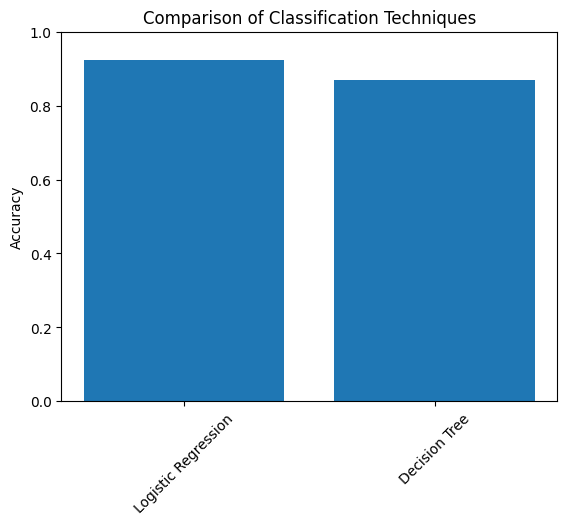

In [32]:
import matplotlib.pyplot as plt

# Plotting the accuracy results
plt.bar(accuracy_results.keys(), accuracy_results.values())
plt.ylabel('Accuracy')
plt.title('Comparison of Classification Techniques')
plt.xticks(rotation=45)
plt.ylim(0, 1)  # Set y-axis limit
plt.show()


In [33]:
def display_prediction_probabilities(model, image, true_label):
    image_reshaped = image.reshape(1, 28, 28)  # Reshape to (1, 28, 28)
    probabilities = model.predict(image_reshaped)
    probabilities = probabilities[0]  # Get the probabilities for the single image

    plt.figure(figsize=(10, 5))
    plt.bar(range(10), probabilities, color='blue', alpha=0.7)
    plt.xticks(range(10), [str(i) for i in range(10)])
    plt.xlabel('Digits')
    plt.ylabel('Probability')
    predicted_label = np.argmax(probabilities)
    plt.title(f'True Label: {true_label}, Predicted Label: {predicted_label}')
    plt.ylim(0, 1)
    plt.show()

#**Neural Network Experiments**

* **Experiment 1**: Running the Model with 64 Neurons
* **Experiment 2**: Running the Model with 128 Neurons (Baseline)
* **Experiment 3**: Running the Model with 256 Neurons
* **Experiment 4**: Running the Model with 1 Hidden Layer
* **Experiment 5**: Running the Model with 2 Hidden Layers
* **Experiment 6**: Running the Model with 3 Hidden Layers
* **Experiment 7**: Running the Model with Dropout (0.2)
* **Experiment 8**: Running the Model with Dropout (0.5)
* **Experiment 9**: Running with a Smaller Learning Rate (0.0001)
* **Experiment 10**: Running with a Larger Learning Rate (0.01)
* **Experiment 11**: Running with Smaller Batch Size (32)
* **Experiment 12**: Running with Larger Batch Size (128)
* **Experiment 13**: Using Sigmoid Activation Instead of ReLU
* **Experiment 14**: Running with Early Stopping



##Experiment 1: Running the model with 64 neurons

Running model with 64 neurons in the hidden layer.


/usr/local/lib/python3.10/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8221 - loss: 0.6427 - val_accuracy: 0.9392 - val_loss: 0.2189
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9416 - loss: 0.2055 - val_accuracy: 0.9560 - val_loss: 0.1559
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9583 - loss: 0.1473 - val_accuracy: 0.9602 - val_loss: 0.1386
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9655 - loss: 0.1197 - val_accuracy: 0.9652 - val_loss: 0.1154
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9712 - loss: 0.0983 - val_accuracy: 0.9683 - val_loss: 0.1057


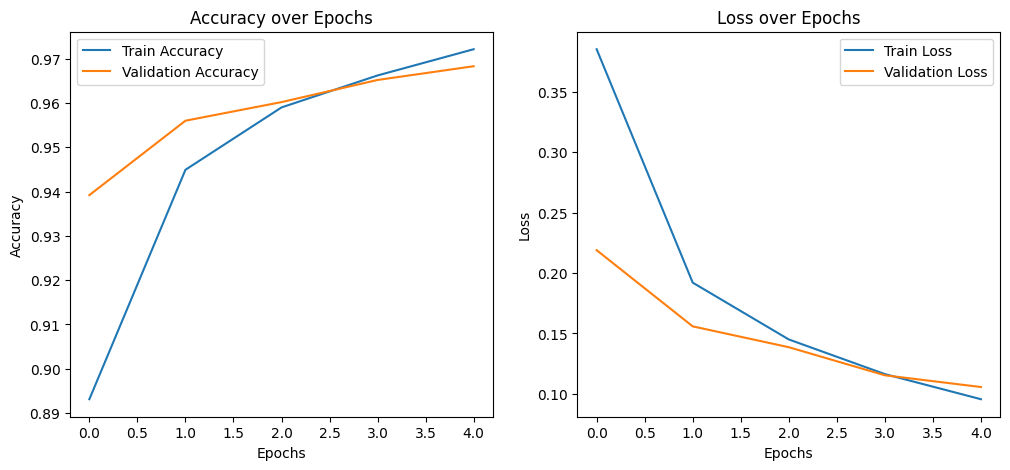

In [34]:
# Concept Explanation:
# This experiment evaluates how the number of neurons affects the model's capacity to learn.
# A model with too few neurons may not learn effectively.

# Code to run the experiment with 64 neurons
print("Running model with 64 neurons in the hidden layer.")
model_64 = build_model(num_neurons=64)
history_64_neurons = train_model(model_64)
plot_learning_curves(history_64_neurons)

# Questions to consider:
# 1. How did the model perform with 64 neurons compared to the baseline?
#    - Look at the final training and validation accuracy.
# 2. Did the model learn quickly?
#    - Examine the learning curves: How many epochs did it take to see significant improvement in accuracy?
# 3. How accurate was the model?
#    - Focus on the final accuracy values reported in the output after training. What were they for both training and validation sets?

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step


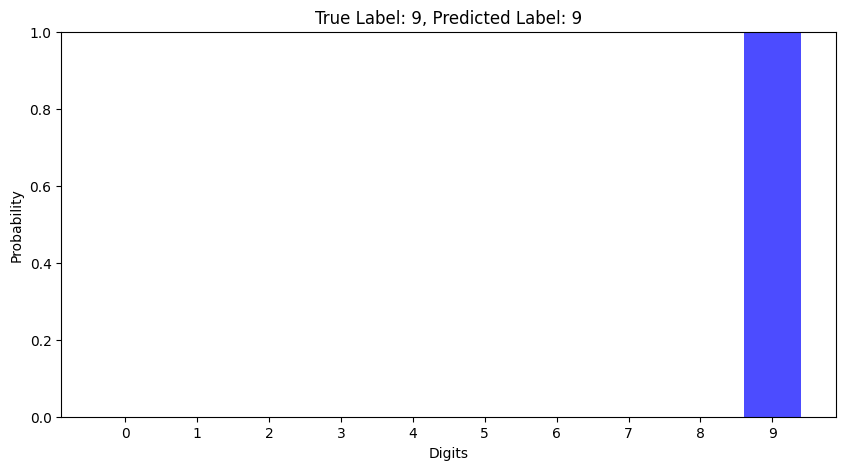

In [36]:
import numpy as np
# Example usage: Display probabilities for a random test image
index = np.random.randint(0, len(x_test))
display_prediction_probabilities(model_64, x_test[index], y_test[index])

**Your Observations:** xxx

##Experiment 2: Running the model with 128 neurons (Baseline)

In [ ]:
# Concept Explanation:
# This experiment establishes a baseline for comparing other configurations.

# Code to run the experiment with 128 neurons
print("Running model with 128 neurons (baseline).")
model_128 = build_model(num_neurons=128)
history_128_neurons = train_model(model_128)
plot_learning_curves(history_128_neurons)

# Questions to consider:
# 1. How well did the model perform with 128 neurons?
#    - Review the final training and validation accuracy values.
# 2. What patterns do you see in the learning curves?
#    - Discuss whether the curves indicate overfitting or underfitting.
# 3. Did the model generalize well to the validation data?
#    - Look for any discrepancies between training and validation accuracy.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step


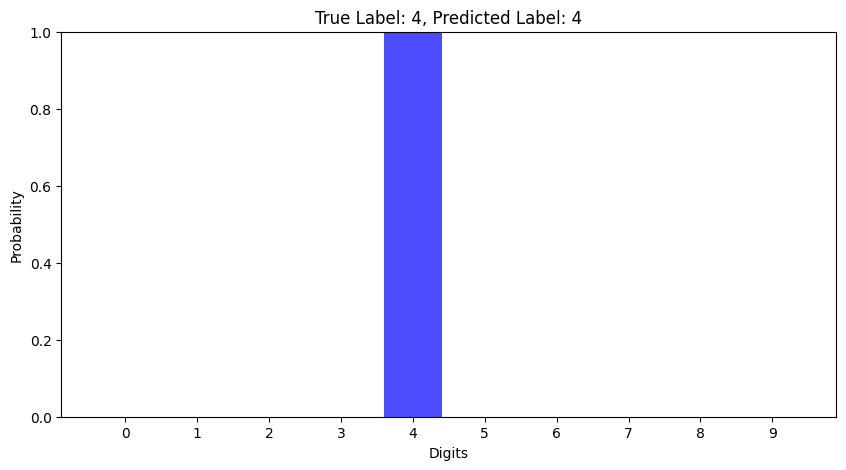

In [37]:
# Example usage: Display probabilities for a random test image
index = np.random.randint(0, len(x_test))
display_prediction_probabilities(model_128, x_test[index], y_test[index])


**Your Observations:** xxx

##Experiment 3: Running the model with 256 neurons

In [ ]:
# Concept Explanation:
# Increasing the number of neurons may improve performance but could lead to overfitting.

# Code to run the experiment with 256 neurons
print("Running model with 256 neurons in the hidden layer.")
model_256 = build_model(num_neurons=256)
history_256_neurons = train_model(model_256)
plot_learning_curves(history_256_neurons)

# Questions to consider:
# 1. Did adding more neurons improve the performance of the model?
#    - Compare final accuracy with the previous models (64 and 128 neurons).
# 2. Did you observe any signs of overfitting?
#    - Check for a significant gap between training and validation accuracy.

In [ ]:
# Example usage: Display probabilities for a random test image
index = np.random.randint(0, len(x_test))
display_prediction_probabilities(model_256, x_test[index], y_test[index])

**Your Observations:** xxx

##Experiment 4: Running the model with 1 hidden layer (baseline)

In [ ]:
# Concept Explanation:
# This experiment examines the importance of network depth.

# Code to run the experiment with 1 hidden layer
print("Running model with 1 hidden layer (baseline).")
model_1_layer = build_model(num_hidden_layers=1)
history_1_hidden_layer = train_model(model_1_layer)
plot_learning_curves(history_1_hidden_layer)

# Questions to consider:
# 1. How does the model perform with just one hidden layer?
#    - Look at the training and validation accuracy.
# 2. Are there any signs of underfitting or overfitting?
#    - Compare performance against deeper models.


**Your Observations:** xxx

##Experiment 5: Running the model with 2 hidden layers

In [ ]:
# Concept Explanation:
# More hidden layers allow for better feature extraction and can improve performance.

# Code to run the experiment with 2 hidden layers
print("Running model with 2 hidden layers.")
model_2_layers = build_model(num_hidden_layers=2)
history_2_hidden_layers = train_model(model_2_layers)
plot_learning_curves(history_2_hidden_layers)

# Questions to consider:
# 1. Did the addition of a second hidden layer improve the model's performance?
#    - Compare the final accuracy with the one-layer model.
# 2. What do you observe in the learning curves?
#    - Analyze convergence speed and stability.

**Your Observations:** xxx

##Experiment 6: Running the model with 3 hidden layers

In [ ]:
# Concept Explanation:
# Increasing complexity may lead to improved performance but also raises the risk of overfitting.

# Code to run the experiment with 3 hidden layers
print("Running model with 3 hidden layers.")
model_3_layers = build_model(num_hidden_layers=3)
history_3_hidden_layers = train_model(model_3_layers)
plot_learning_curves(history_3_hidden_layers)

# Questions to consider:
# 1. How does the model performance change with three hidden layers?
#    - Compare the final accuracy with models having fewer layers.
# 2. Are there any noticeable differences in convergence speed or final accuracy?
#    - Look for any improvement in learning stability.

**Your Observations:** xxx

##Experiment 7: Running with a smaller learning rate (0.0001)

In [ ]:
# Concept Explanation:
# A smaller learning rate can lead to more stable training but may slow convergence.

# Code to run the experiment with a smaller learning rate
print("Running model with a smaller learning rate (0.0001).")
model_small_lr = build_model()
history_small_lr = train_model(model_small_lr, learning_rate=0.0001)
plot_learning_curves(history_small_lr)

# Questions to consider:
# 1. How did the smaller learning rate affect the training speed and accuracy?
#    - Look at the number of epochs taken to achieve a certain accuracy.
# 2. Did the model reach a lower final accuracy compared to the default learning rate?
#    - Compare results with the baseline model.

**Your Observations:** xxx

##Experiment 8: Running with a Larger Learning Rate (0.01)

In [ ]:
# Concept Explanation:
# A larger learning rate can lead to faster convergence but may cause instability.

# Code to run the experiment with a larger learning rate
print("Running model with a larger learning rate (0.01).")
model_large_lr = build_model()
history_large_lr = train_model(model_large_lr, learning_rate=0.01)
plot_learning_curves(history_large_lr)

# Questions to consider:
# 1. Did the larger learning rate help the model converge faster?
#    - Assess the learning curves for convergence speed.
# 2. Were there any signs of instability in the training process?
#    - Look for erratic behavior in the loss or accuracy.

**Your Observations:** xxx

##Experiment 9: Running with Smaller Batch Size (32)

In [ ]:
# Concept Explanation:
# Smaller batch sizes can introduce more variability in training.

# Code to run the experiment with a smaller batch size
print("Running model with smaller batch size (32).")
model_small_batch = build_model()
history_small_batch = train_model(model_small_batch, batch_size=32)
plot_learning_curves(history_small_batch)

# Questions to consider:
# 1. How does the model perform with a smaller batch size?
#    - Compare the final accuracy with the larger batch size.
# 2. Is there more fluctuation in the learning curves compared to the baseline?
#    - Analyze the stability of accuracy and loss curves.

**Your Observations:** xxx

##Experiment 10: Running with Larger Batch Size (128)



In [ ]:
# Concept Explanation:
# Larger batch sizes lead to smoother training but may slow down convergence.

# Code to run the experiment with a larger batch size
print("Running model with larger batch size (128).")
model_large_batch = build_model()
history_large_batch = train_model(model_large_batch, batch_size=128)
plot_learning_curves(history_large_batch)

# Questions to consider:
# 1. How does the model perform with a larger batch size?
#    - Look at the accuracy and loss values compared to smaller sizes.
# 2. Does it show smoother learning curves, and what impact does that have on training time?
#    - Assess convergence and overall stability of training.

**Your Observations:** xxx

##Experiment 11: Running the Model with Dropout (0.2)

In [ ]:
# Concept Explanation:
# Dropout is a regularization technique to prevent overfitting.

# Code to run the experiment with dropout
print("Running model with dropout rate of 0.2.")
model_dropout_02 = build_model(dropout_rate=0.2)
history_dropout_02 = train_model(model_dropout_02)
plot_learning_curves(history_dropout_02)

# Questions to consider:
# 1. How does the model perform with a dropout rate of 0.2?
#    - Compare training accuracy with the baseline model.
# 2. Is there a noticeable difference in accuracy compared to a model without dropout?
#    - Analyze the impact of dropout on validation accuracy.

**Your Observations:** xxx

##Experiment 12: Running the Model with Dropout (0.5)

In [ ]:
# Concept Explanation:
# Increasing dropout can further help in reducing overfitting but may lower training accuracy.

# Code to run the experiment with dropout
print("Running model with dropout rate of 0.5.")
model_dropout_05 = build_model(dropout_rate=0.5)
history_dropout_05 = train_model(model_dropout_05)
plot_learning_curves(history_dropout_05)

# Questions to consider:
# 1. How does the model perform with a dropout rate of 0.5?
#    - Check final accuracy compared to lower dropout rates.
# 2. Does a higher dropout rate significantly affect training accuracy?
#    - Analyze the balance between overfitting and performance.

**Your Observations:** xxx

##Experiment 13: Using Sigmoid Activation Instead of ReLU

In [ ]:
# Concept Explanation:
# Different activation functions can impact the learning dynamics of the model.

# Code to run the experiment with sigmoid activation
print("Running model with sigmoid activation.")
model_sigmoid = build_model(activation='sigmoid')
history_sigmoid = train_model(model_sigmoid)
plot_learning_curves(history_sigmoid)

# Questions to consider:
# 1. How does the model perform with sigmoid activation compared to ReLU?
#    - Assess final accuracy and learning stability.
# 2. Did you notice any difference in the speed of learning or final performance?
#    - Discuss the implications of using different activation functions.

**Your Observations:** xxx

##Experiment 14: Running with Early Stopping

In [ ]:
# Concept Explanation:
# Early stopping helps prevent overfitting by monitoring validation loss and stopping training once it begins to increase.

# Code to run the experiment with early stopping
from tensorflow.keras.callbacks import EarlyStopping

print("Running model with early stopping.")
model_early_stopping = build_model()
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_early_stopping = model_early_stopping.fit(x_train, y_train, epochs=20, batch_size=64,
                                                  validation_data=(x_val, y_val),
                                                  callbacks=[early_stopping])

plot_learning_curves(history_early_stopping)

# Questions to consider:
# 1. How did early stopping affect the model's performance?
#    - Compare the final training and validation accuracy.
# 2. Did it lead to better generalization on the validation set?
#    - Discuss the impact of stopping training early on model performance.

**Your Observations:** xxx

##Overall Observation

Based on the results of the 14 experiments, how do different hyperparameters, model architectures, and training techniques impact the performance of neural networks compared to traditional classification methods? In your response, consider aspects such as accuracy, loss, generalization, and computational efficiency.

**Your Observations:** xxx